In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [12]:
df=pd.read_csv(r"C:\Users\haris\.vscode\youtube analysis\youtube_ad_revenue_dataset.csv")

In [13]:
df.drop_duplicates(inplace=True)

# Convert date
df["date"] = pd.to_datetime(df["date"])

In [28]:
df.isna().sum()

views                       0
likes                    6000
comments                 6000
watch_time_minutes       6000
video_length_minutes        0
subscribers                 0
category                    0
device                      0
country                     0
ad_revenue_usd              0
engagement_rate         11696
views_per_subscriber        0
year                        0
month                       0
day                         0
dtype: int64

In [29]:
df[['views','likes','comments','watch_time_minutes']].skew()

views                -0.002912
likes                -0.002202
comments              0.008230
watch_time_minutes    0.001531
dtype: float64

<Axes: ylabel='Density'>

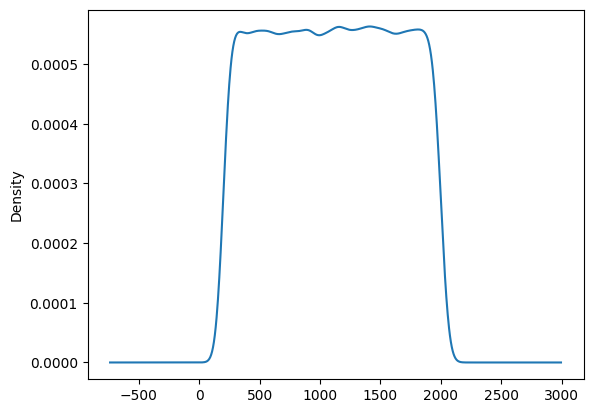

In [30]:
df['likes'].plot(kind='kde')

<Axes: >

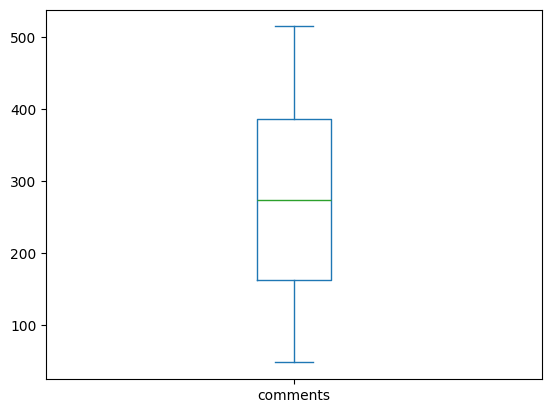

In [31]:
df['comments'].plot(kind='box')

In [14]:
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["views"]
df["views_per_subscriber"] = df["views"] / df["subscribers"]

# Extract date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [15]:
df = df.drop(["video_id", "date"], axis=1)

In [16]:
X = df.drop("ad_revenue_usd", axis=1)
y = df["ad_revenue_usd"]

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   views                 120000 non-null  int64  
 1   likes                 114000 non-null  float64
 2   comments              114000 non-null  float64
 3   watch_time_minutes    114000 non-null  float64
 4   video_length_minutes  120000 non-null  float64
 5   subscribers           120000 non-null  int64  
 6   category              120000 non-null  object 
 7   device                120000 non-null  object 
 8   country               120000 non-null  object 
 9   ad_revenue_usd        120000 non-null  float64
 10  engagement_rate       108304 non-null  float64
 11  views_per_subscriber  120000 non-null  float64
 12  year                  120000 non-null  int32  
 13  month                 120000 non-null  int32  
 14  day                   120000 non-null  int32  
dtypes: fl

In [33]:
df['views'].value_counts()

views
9999     520
10023    516
10019    516
9982     512
9993     503
        ... 
9537       1
10337      1
9610       1
9691       1
10335      1
Name: count, Length: 736, dtype: int64

In [54]:
df.corr(numeric_only=True)["ad_revenue_usd"].sort_values(ascending=False)

ad_revenue_usd          1.000000
watch_time_minutes      0.988869
engagement_rate         0.150782
likes                   0.146269
views                   0.037942
comments                0.034494
subscribers             0.005065
year                    0.001053
month                   0.000872
video_length_minutes    0.000364
views_per_subscriber   -0.002023
day                    -0.002444
Name: ad_revenue_usd, dtype: float64

In [42]:


num_cont_normal = [
    'views', 'likes', 'comments',
    'watch_time_minutes', 'video_length_minutes',
    'subscribers', 'engagement_rate'
]

num_cont_skewed = [
    'views_per_subscriber'
]

num_disc = [
    'year', 'month', 'day'
]

cat_cols = [
    'category', 'device', 'country'
]

In [35]:
df[
    ['views', 'likes', 'comments',
     'watch_time_minutes', 'video_length_minutes',
     'engagement_rate', 'views_per_subscriber']
].skew()

views                   -0.002912
likes                   -0.002202
comments                 0.008230
watch_time_minutes       0.001531
video_length_minutes    -0.001861
engagement_rate         -0.002883
views_per_subscriber    16.035549
dtype: float64

In [50]:
df[num_cont_normal].skew()

views                  -0.002912
likes                  -0.002202
comments                0.008230
watch_time_minutes      0.001531
video_length_minutes   -0.001861
subscribers            -0.009575
engagement_rate        -0.002883
dtype: float64

In [43]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np
log_transform = FunctionTransformer(np.log1p)

In [44]:
normal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


skew_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

num_disc_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [45]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('normal', normal_pipe, num_cont_normal),
    ('skewed', skew_pipe, num_cont_skewed),
    ('cat', cat_pipe, cat_cols),
    ('disc', num_disc_pipe, num_disc)
])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [49]:
results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append([name, r2, rmse, mae])

In [51]:
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE", "MAE"])
results_df = results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print(results_df)

               Model  R2 Score       RMSE       MAE
0  Linear Regression  0.952583  13.478778  3.112286
1  Gradient Boosting  0.952204  13.532571  3.692611
2              Lasso  0.951567  13.622349  4.322619
3      Random Forest  0.949721  13.879569  3.576265
4      Decision Tree  0.895040  20.053694  5.531591


In [52]:
final_model = LinearRegression()

final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('normal', ...), ('skewed', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [53]:
joblib.dump(final_pipeline, "youtube_pipeline.pkl")

['youtube_pipeline.pkl']